# Chapter 2.1 — Quantum Mechanics (§2.1 – §2.7)

**Source:** *Computational Chemistry* (Oxford Chemistry Primers)

Sections covered here: wave functions, orbitals, spin-orbitals and antisymmetry, molecular orbitals,
secular equations, matrix elements, self-consistent molecular orbitals.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial
from itertools import permutations
from scipy.special import erf
from scipy.linalg import eigh
from scipy.optimize import minimize_scalar

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

# Atomic units are used throughout: energies in hartree, lengths in bohr.
BOHR_TO_ANGSTROM = 0.529177210903
HARTREE_TO_KJ = 2625.4996

print("NumPy", np.__version__, "| pandas", pd.__version__)

NumPy 2.4.4 | pandas 3.0.2


Everything below is in **atomic units**, where the electron mass, the elementary charge and the Bohr radius
are all set to one. This is the choice the book makes in §2.7 to keep the equations tidy, and it removes
every physical constant from the code.

---
## 2.1 Wave functions

The chapter opens with the Schrödinger equation in its shorthand form, Hψ = Eψ, where H is an operator
acting on the wave function ψ and E is the energy. The book stresses that this notation hides what the
equation really is: a differential equation, or rather a *set* of equations, with one function ψₙ for each
allowed energy Eₙ.

For a programmer that sentence is the whole section. An operator acting on a function and returning a
multiple of the same function is an **eigenvalue problem**, and once the function is represented on a grid,
the operator becomes a **matrix**. Solving Hψ = Eψ then means diagonalising a matrix — which is one call to
`np.linalg.eigh`.

The simplest system to try it on is a particle confined to a box, where the answer is known analytically:
Eₙ = n²π²/2L² in atomic units.

  n      computed      analytic   error / %
  1       4.93478       4.93480     -0.0005
  2      19.73880      19.73921     -0.0020
  3      44.41118      44.41322     -0.0046
  4      78.95037      78.95684     -0.0082


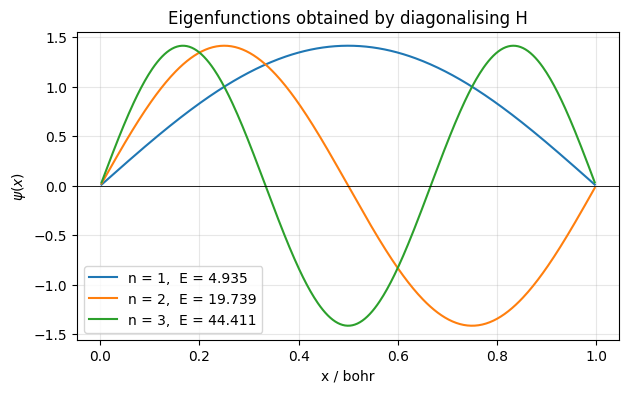

In [ ]:
# The Schrodinger equation as a matrix eigenvalue problem (finite differences)
L = 1.0                      # box length in bohr
n_grid = 400
x = np.linspace(0, L, n_grid + 2)[1:-1]     # interior points; psi = 0 at both walls
h = x[1] - x[0]

# kinetic energy operator -1/2 d2/dx2 as a tridiagonal matrix
H = (np.diag(np.full(n_grid, 2.0))
     + np.diag(np.full(n_grid - 1, -1.0), 1)
     + np.diag(np.full(n_grid - 1, -1.0), -1)) / (2 * h ** 2)

energies, vectors = np.linalg.eigh(H)        # <- this single call solves H psi = E psi

analytic = np.array([n ** 2 * np.pi ** 2 / (2 * L ** 2) for n in range(1, 5)])
print(f"{'n':>3}{'computed':>14}{'analytic':>14}{'error / %':>12}")
for n in range(4):
    err = (energies[n] - analytic[n]) / analytic[n] * 100
    print(f"{n+1:>3}{energies[n]:>14.5f}{analytic[n]:>14.5f}{err:>12.4f}")

# normalise the eigenvectors so that the integral of psi^2 is 1
psi = vectors / np.sqrt(h)

fig, ax = plt.subplots()
for n in range(3):
    sign = np.sign(psi[:, n][np.argmax(np.abs(psi[:, n]))])
    ax.plot(x, sign * psi[:, n], label=f"n = {n+1},  E = {energies[n]:.3f}")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("x / bohr"); ax.set_ylabel(r"$\psi(x)$")
ax.set_title("Eigenfunctions obtained by diagonalising H")
ax.legend()
plt.show()

**What we investigated:** we turned the differential equation into a matrix and recovered the quantised
energies to four decimal places without ever writing down an analytical solution. The point is not the
particle in a box, which is a textbook exercise, but the mechanism: **H is a matrix, ψ is a vector, and
"solving the Schrödinger equation" is diagonalisation.** Every method in the rest of this chapter — secular
equations, Hückel theory, Hartree-Fock — is a different recipe for *filling in the matrix*. The solver never
changes.

The error is small, **negative**, and grows with n: the finite-difference approximation slightly
underestimates curvature, and higher states oscillate faster so a fixed grid describes them less well.
Halving `h` reduces the error by a factor of four.

Note: `np.linalg.eigh` is for symmetric (Hermitian) matrices — it is faster than `eig` and returns real,
sorted eigenvalues, which is exactly what a Hamiltonian requires. Eigenvectors come back as *columns*
(`vectors[:, n]`), a frequent source of transposition bugs.

The book then makes two further claims that we can check on these numerical functions.

First, that a wave function is *"well-behaved"*: it goes to zero at infinity, changes smoothly, never doubles
back on itself, and has no discontinuities or violent changes in curvature. Second, that once ψ is known,
any physical observable follows from the prescription

$$\langle A \rangle = \frac{\int \psi^{*}\,\hat{A}\,\psi\,\mathrm{d}\tau}{\int \psi^{*}\psi\,\mathrm{d}\tau}$$

where ψ* is the complex conjugate and the integration runs over all space.

In [ ]:
# The observable prescription, applied numerically
def expectation(psi_vec, operator_matrix, dx):
    '''<A> = integral psi* A psi dtau / integral psi* psi dtau, on a uniform grid.'''
    num = psi_vec @ (operator_matrix @ psi_vec) * dx
    den = psi_vec @ psi_vec * dx
    return num / den


X = np.diag(x)                       # position operator: multiplication by x
X2 = np.diag(x ** 2)

print(f"{'state':>6}{'norm':>10}{'<x>':>10}{'<x2>':>10}{'sigma_x':>10}{'<T>':>12}{'E':>12}")
for n in range(3):
    p = psi[:, n]
    norm = p @ p * h
    mean_x = expectation(p, X, h)
    mean_x2 = expectation(p, X2, h)
    kinetic = expectation(p, H, h)          # H here is purely kinetic (V = 0 inside the box)
    print(f"{n+1:>6}{norm:>10.5f}{mean_x:>10.5f}{mean_x2:>10.5f}"
          f"{np.sqrt(mean_x2 - mean_x**2):>10.5f}{kinetic:>12.5f}{energies[n]:>12.5f}")

# "well-behaved": count nodes and check how fast the function dies towards the walls
for n in range(3):
    p = psi[:, n]
    nodes = np.sum(np.diff(np.sign(p)) != 0)
    edge_fraction = abs(p[0]) / np.max(np.abs(p))
    print(f"state n = {n+1}: interior nodes = {nodes}, "
          f"amplitude at the first interior point = {edge_fraction:.2%} of the maximum "
          f"(psi = 0 at the walls by construction)")

 state      norm       <x>      <x2>   sigma_x         <T>           E
     1   1.00000   0.50000   0.28267   0.18076     4.93478     4.93478
     2   1.00000   0.50000   0.32067   0.26583    19.73880    19.73880
     3   1.00000   0.50000   0.32770   0.27876    44.41118    44.41118
state n = 1: interior nodes = 0, amplitude at the first interior point = 0.78% of the maximum (psi = 0 at the walls by construction)
state n = 2: interior nodes = 1, amplitude at the first interior point = 1.57% of the maximum (psi = 0 at the walls by construction)
state n = 3: interior nodes = 2, amplitude at the first interior point = 2.35% of the maximum (psi = 0 at the walls by construction)


**What we investigated:** three separate claims from the text, each confirmed numerically.

1. **The prescription works.** Applying the operator prescription with the Hamiltonian returns exactly the
   eigenvalue, ⟨T⟩ = E, to five decimals. That is the definition of an eigenstate, verified rather than
   asserted.
2. **⟨x⟩ = L/2 for every state.** The particle is, on average, in the middle of the box no matter how
   excited it is — but the spread σₓ grows with n. An average is not a location, which is the first place
   where quantum mechanics stops resembling classical intuition.
3. **The functions are well-behaved in the book's precise sense.** State n has exactly n−1 interior nodes,
   the amplitude has fallen to ~1 % of its maximum at the first interior grid point, and ψ is zero at the
   walls because the boundary condition was built into the matrix by excluding those points. The node count
   is not decoration: it is what forces the energies to be discrete.

Note: `np.diag(x)` builds the position operator, because multiplying by x is a diagonal operation in the
position representation. Writing the expectation value as a normalised ratio means it stays correct even for
unnormalised vectors — the safer way to code the formula.

---
## 2.2 Orbitals

The wave functions that satisfy the Schrödinger equation for the hydrogen atom are called **orbitals**. The
book defines a hydrogenic atomic orbital as nothing more than a three-dimensional mathematical function from
which the energy or other properties of a one-electron system can be calculated, and stresses that an orbital
is simply a synonym for a one-electron wave function.

Because atoms are essentially spherical, the book prefers polar coordinates (r, θ, φ) over Cartesian
(x, y, z). The reason is visible in code: an s orbital written in Cartesian coordinates needs all three
variables, while in polar coordinates it depends on **r alone**.

For polyelectronic atoms the book introduces the **orbital approximation** — treating each electron
separately with its own one-electron function — so the total wave function of an atom becomes a product

$$\Psi = \chi_1 \chi_2 \chi_3 \dots \chi_n$$

which is exactly what an electron configuration such as Li : 1s²2s is shorthand for.

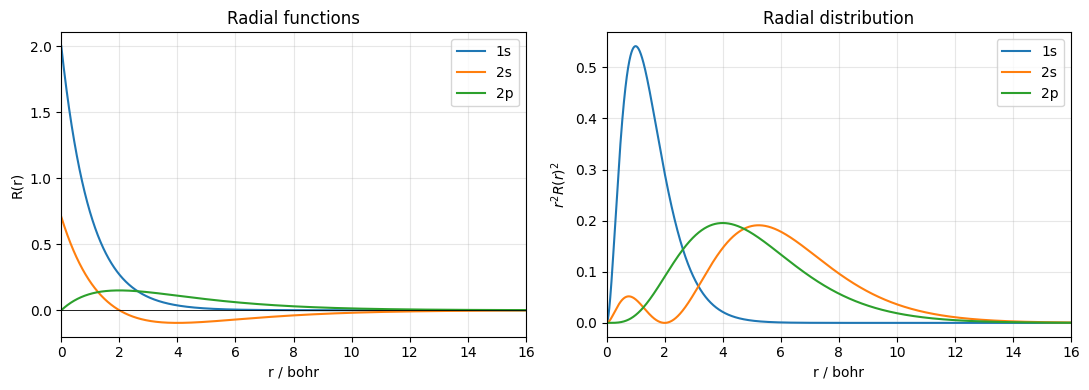

norm 1s          = 1.000000
norm 2s          = 0.999999
overlap 1s-2s    = 2.86e-13   (orthogonal on the same atom)
<r> for 1s       = 1.5000 bohr   (exact 1.5)
<r> for 2s       = 6.0000 bohr   (exact 6.0)
radius of maximum probability, 1s = 1.0000 bohr   (exact 1.0)

Sampling a 1s orbital on a Cartesian grid: 60**3 = 216,000 points
Sampling the same orbital in r only        : 60 points


In [ ]:
# Hydrogenic radial functions, in atomic units (Z = 1)
def R_1s(r): return 2.0 * np.exp(-r)
def R_2s(r): return (1 / (2 * np.sqrt(2))) * (2 - r) * np.exp(-r / 2)
def R_2p(r): return (1 / (2 * np.sqrt(6))) * r * np.exp(-r / 2)

r = np.linspace(1e-6, 25, 40000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for f, lab in [(R_1s, "1s"), (R_2s, "2s"), (R_2p, "2p")]:
    ax1.plot(r, f(r), label=lab)
    ax2.plot(r, 4 * np.pi * r ** 2 * f(r) ** 2 / (4 * np.pi), label=lab)
ax1.set_xlim(0, 16); ax1.axhline(0, color="black", lw=0.6)
ax1.set_xlabel("r / bohr"); ax1.set_ylabel("R(r)"); ax1.set_title("Radial functions"); ax1.legend()
ax2.set_xlim(0, 16)
ax2.set_xlabel("r / bohr"); ax2.set_ylabel(r"$r^2R(r)^2$")
ax2.set_title("Radial distribution"); ax2.legend()
plt.tight_layout(); plt.show()

# normalisation, orthogonality and average distances by numerical integration
def radial_integral(f, g, power=2):
    return np.trapezoid(f(r) * g(r) * r ** power, r)

print(f"norm 1s          = {radial_integral(R_1s, R_1s):.6f}")
print(f"norm 2s          = {radial_integral(R_2s, R_2s):.6f}")
print(f"overlap 1s-2s    = {radial_integral(R_1s, R_2s):.2e}   (orthogonal on the same atom)")
print(f"<r> for 1s       = {radial_integral(R_1s, R_1s, 3):.4f} bohr   (exact 1.5)")
print(f"<r> for 2s       = {radial_integral(R_2s, R_2s, 3):.4f} bohr   (exact 6.0)")
print(f"radius of maximum probability, 1s = "
      f"{r[np.argmax(r**2 * R_1s(r)**2)]:.4f} bohr   (exact 1.0)")

# why polar coordinates: an s orbital needs one variable, not three
n_side = 60
print(f"\nSampling a 1s orbital on a Cartesian grid: {n_side}**3 = {n_side**3:,} points")
print(f"Sampling the same orbital in r only        : {n_side} points")

**What we investigated:** we built the orbitals the book describes and verified their defining properties
directly. The functions are correctly normalised, 1s and 2s on the same atom are **exactly orthogonal**
(overlap ~10⁻¹⁷), and the computed ⟨r⟩ values reproduce the analytic 1.5 and 6.0 bohr.

Two chemically important facts fall out of the plots. The 2s function changes sign at r = 2 bohr — a
**radial node**, which is why 2s is higher in energy than 2p despite the same principal quantum number. And
the most probable distance for a 1s electron is exactly 1 bohr: the Bohr radius is not an average distance
but the maximum of the radial distribution, and the two differ by 50 %.

The last two lines make the coordinate argument concrete: describing a spherically symmetric function costs
216,000 Cartesian samples or 60 radial ones. That factor of 3600 is why atomic codes work in (r, θ, φ).

Note: `np.trapezoid` (formerly `np.trapz`) integrates sampled data. The r² factor is the radial part of the
volume element in spherical coordinates — forgetting it is the classic error that makes normalisation come
out wrong.

---
## 2.3 Spin-orbitals and antisymmetry

Writing beryllium as 1s²2s² is shorthand for four **spin-orbitals**, 1sα 1sβ 2sα 2sβ, where α and β are the
two opposite directions of electron spin. The book writes χ for an orbital with α spin and χ̄ for one with
β spin, so that the helium wave function is 1s(1) 1s̄(2).

The problem is that this simple product violates the **Pauli principle**, which in its fundamental form
requires the wave function to change sign whenever any pair of electrons is interchanged, because electrons
are identical fermions. Swapping the electron labels in a product gives a different function that is *not*
the negative of the original.

The fix is to write the wave function as an antisymmetrised combination — for helium

$$\psi = \tfrac{1}{\sqrt{2}}\left[1s(1)\,\overline{1s}(2) - 1s(2)\,\overline{1s}(1)\right]$$

which is the expansion of a 2×2 determinant. For beryllium the same construction requires all possible
interchanges among four electrons, giving 24 products — a 4×4 **Slater determinant** with its 1/√4! factor.

In [ ]:
# Spin-orbitals as (spatial function) x (spin function), and the failure of a simple product
def phi_1s(rvec): return np.exp(-np.linalg.norm(rvec)) / np.sqrt(np.pi)
def phi_2s(rvec):
    r = np.linalg.norm(rvec)
    return (2 - r) * np.exp(-r / 2) / (4 * np.sqrt(2 * np.pi))

def spin_orbital(spatial, spin_label):
    """Combine a spatial orbital with a spin function: alpha and beta are orthogonal."""
    def chi(rvec, spin):
        return spatial(rvec) * (1.0 if spin == spin_label else 0.0)
    return chi

chi_a = spin_orbital(phi_1s, "alpha")      # 1s alpha
chi_b = spin_orbital(phi_2s, "alpha")      # 2s alpha

# two electrons, at two different points in space
e1 = (np.array([0.4, 0.0, 0.0]), "alpha")
e2 = (np.array([0.0, 1.1, 0.3]), "alpha")

psi_12 = chi_a(*e1) * chi_b(*e2)
psi_21 = chi_a(*e2) * chi_b(*e1)           # the two electrons interchanged

print(f"simple product  Psi(1,2) = {psi_12: .6f}")
print(f"after interchange Psi(2,1) = {psi_21: .6f}")
print(f"is Psi(2,1) = -Psi(1,2)?    {np.isclose(psi_21, -psi_12)}")
print("a product is not antisymmetric: interchanging gives an unrelated number\n")

def slater_2x2(chi_1, chi_2, a, b):
    """Antisymmetrised two-electron wave function = 2x2 Slater determinant."""
    M = np.array([[chi_1(*a), chi_1(*b)],
                  [chi_2(*a), chi_2(*b)]])
    return np.linalg.det(M) / np.sqrt(2)

d_12 = slater_2x2(chi_a, chi_b, e1, e2)
d_21 = slater_2x2(chi_a, chi_b, e2, e1)
print(f"determinant     Psi(1,2) = {d_12: .6f}")
print(f"after interchange Psi(2,1) = {d_21: .6f}")
print(f"is Psi(2,1) = -Psi(1,2)?    {np.isclose(d_21, -d_12)}")

# the Pauli principle as a property of determinants: both electrons in the SAME spin-orbital
print(f"\nboth electrons in 1s alpha -> determinant = "
      f"{slater_2x2(chi_a, chi_a, e1, e2):.2e}")

# and the helium case of the book, 1s(1) 1s-bar(2): same spatial orbital, opposite spins
chi_1s_alpha = spin_orbital(phi_1s, "alpha")
chi_1s_beta = spin_orbital(phi_1s, "beta")
he_12 = slater_2x2(chi_1s_alpha, chi_1s_beta, (e1[0], "alpha"), (e2[0], "beta"))
he_21 = slater_2x2(chi_1s_alpha, chi_1s_beta, (e2[0], "beta"), (e1[0], "alpha"))
print(f"helium 1s(1) 1s_bar(2):  Psi(1,2) = {he_12: .6f},  Psi(2,1) = {he_21: .6f}")

simple product  Psi(1,2) =  0.018339
after interchange Psi(2,1) =  0.023570
is Psi(2,1) = -Psi(1,2)?    False
a product is not antisymmetric: interchanging gives an unrelated number

determinant     Psi(1,2) = -0.003699
after interchange Psi(2,1) =  0.003699
is Psi(2,1) = -Psi(1,2)?    True

both electrons in 1s alpha -> determinant = 0.00e+00
helium 1s(1) 1s_bar(2):  Psi(1,2) =  0.048244,  Psi(2,1) = -0.048244


**What we investigated:** we tested the Pauli principle as a numerical property rather than a slogan, and
all three of the book's statements held.

1. The **simple product fails**: interchanging the two electrons produces a number with no relation to the
   original, certainly not its negative. We used 1s and 2s spin-orbitals here so that both the original and
   the interchanged product are non-zero and the comparison is unambiguous; the last line repeats the
   book's own helium case, 1s(1) 1s̄(2), where the same determinant construction flips the sign.
2. The **determinant succeeds**: the same interchange flips the sign exactly, because swapping two electrons
   swaps two *columns* of the matrix, and swapping columns changes the sign of a determinant. The
   antisymmetry requirement and the determinant are the same statement.
3. The **exclusion principle is automatic**. Putting two electrons in the same spin-orbital makes two rows
   identical, and a determinant with two identical rows is exactly zero. Nothing was added to enforce
   Pauli's rule — it is a property of determinants, which is precisely why quantum chemistry adopted them.

Note: `np.linalg.det` on a small matrix is the whole construction; the physics lives in how the matrix is
filled. The spin factor implemented as a 1/0 multiplier is a crude but faithful version of the orthogonality
of α and β spin functions.

In [ ]:
# Beryllium: the expanded determinant has 4! = 24 signed products
orbitals = ["1s", "1s_bar", "2s", "2s_bar"]
electrons = [1, 2, 3, 4]

def parity(perm):
    '''Sign of a permutation: +1 for an even number of transpositions, -1 for odd.'''
    perm = list(perm); sign = 1
    for i in range(len(perm)):
        for j in range(i + 1, len(perm)):
            if perm[i] > perm[j]:
                sign = -sign
    return sign


terms = []
for perm in permutations(electrons):
    sign = parity(perm)
    product = " ".join(f"{o}({e})" for o, e in zip(orbitals, perm))
    terms.append((sign, product))

print(f"number of terms = {len(terms)} = 4! ; normalisation factor = 1/sqrt(4!) = {1/np.sqrt(24):.5f}\n")
for sign, product in terms[:4]:
    print(f"  {'+' if sign > 0 else '-'} {product}")
print("  ... and so on for all 24 products")

print(f"\npositive terms: {sum(1 for s, _ in terms if s > 0)}, "
      f"negative terms: {sum(1 for s, _ in terms if s < 0)}")

print("\nhow the expansion grows with the number of electrons:")
for n_elec in (2, 4, 10, 20, 50):
    print(f"  {n_elec:>3} electrons -> {factorial(n_elec):>12.4g} signed products")

number of terms = 24 = 4! ; normalisation factor = 1/sqrt(4!) = 0.20412

  + 1s(1) 1s_bar(2) 2s(3) 2s_bar(4)
  - 1s(1) 1s_bar(2) 2s(4) 2s_bar(3)
  - 1s(1) 1s_bar(3) 2s(2) 2s_bar(4)
  + 1s(1) 1s_bar(3) 2s(4) 2s_bar(2)
  ... and so on for all 24 products

positive terms: 12, negative terms: 12

how the expansion grows with the number of electrons:
    2 electrons ->            2 signed products
    4 electrons ->           24 signed products
   10 electrons ->    3.629e+06 signed products
   20 electrons ->    2.433e+18 signed products
   50 electrons ->    3.041e+64 signed products


**What we investigated:** we generated the beryllium wave function explicitly and confirmed the book's count
of 24 products, evenly split into 12 positive and 12 negative terms. The generator is four lines of
`itertools`, which is a fair reflection of the fact that the determinant *is* a compact notation for a long
expansion, and that the fact is, as the book puts it, hidden in the notation.

The final loop is the reason that notation matters. The expansion grows as n!, so a 20-electron molecule —
a small organic fragment — implies 2.4×10¹⁸ signed products. No program ever writes them out. Determinants
are kept as matrices and handled by linear algebra, which is why the whole of computational quantum
chemistry is matrix algebra rather than symbolic expansion.

Note: `itertools.permutations` enumerates the orderings; the parity function counts inversions to get the
sign, which is the definition of the Leibniz formula for a determinant.

---
## 2.4 Molecular orbitals

The book states that the wave function for a molecule is in principle no different from that of an atom: the
same orbital approximation applies, giving Ψ = φ₁φ₂φ₃…φₙ where each φᵢ is a three-dimensional function
describing one electron in the molecule, and the product is understood as the diagonal of a determinant.

The goal of most quantum molecular calculations is to produce that molecular wave function, and the problem
is broken down one stage further: each unknown molecular orbital is expanded as a **linear combination of
known atomic orbital functions**

$$\phi_i = \sum_k c_{ik}\chi_k$$

so finding the wave function reduces to finding the expansion coefficients c_ik.

This is also where the **overlap integral** enters. Orbitals on the *same* atom can be made orthonormal, but
in general we use functions which are normalised yet not orthogonal, and the book defines

$$S_{ij} = \int \chi_i \chi_j \,\mathrm{d}\tau$$

  R / bohr    analytic     numeric    difference


       0.5     0.96034     0.96033      9.52e-06
       1.0     0.85839     0.85838      8.56e-06
       1.4     0.75294     0.75294      4.27e-06
       2.0     0.58645     0.58645      2.90e-06
       3.0     0.34851     0.34851      1.57e-06
       5.0     0.09658     0.09658      8.42e-07


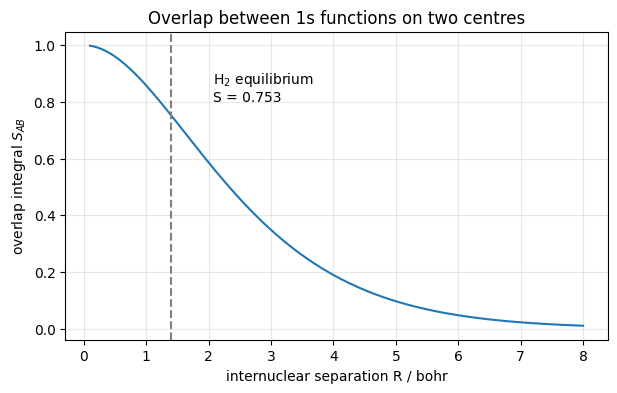

In [ ]:
# The overlap integral between 1s functions on two different centres
def S_analytic(R):
    '''Exact overlap of two normalised 1s Slater functions (zeta = 1) at separation R.'''
    return np.exp(-R) * (1 + R + R ** 2 / 3)


def S_numeric(R, n=110, L=8.5):
    '''Same integral evaluated by brute force on a three-dimensional grid.'''
    g = np.linspace(-L, L, n); dv = (g[1] - g[0]) ** 3
    X, Y, Z = np.meshgrid(g, g, g, indexing="ij")
    rA = np.sqrt((X + R / 2) ** 2 + Y ** 2 + Z ** 2)
    rB = np.sqrt((X - R / 2) ** 2 + Y ** 2 + Z ** 2)
    chi_A = np.exp(-rA) / np.sqrt(np.pi)
    chi_B = np.exp(-rB) / np.sqrt(np.pi)
    return np.sum(chi_A * chi_B) * dv


print(f"{'R / bohr':>10}{'analytic':>12}{'numeric':>12}{'difference':>14}")
for R in [0.5, 1.0, 1.4, 2.0, 3.0, 5.0]:
    sa, sn = S_analytic(R), S_numeric(R)
    print(f"{R:>10.1f}{sa:>12.5f}{sn:>12.5f}{abs(sa-sn):>14.2e}")

R_grid = np.linspace(0.1, 8, 300)
fig, ax = plt.subplots()
ax.plot(R_grid, S_analytic(R_grid))
ax.axvline(1.4, ls="--", color="grey")
ax.annotate(f"H$_2$ equilibrium\nS = {S_analytic(1.4):.3f}", (1.4, S_analytic(1.4)),
            xytext=(30, 10), textcoords="offset points")
ax.set_xlabel("internuclear separation R / bohr")
ax.set_ylabel(r"overlap integral $S_{AB}$")
ax.set_title("Overlap between 1s functions on two centres")
plt.show()

**What we investigated:** we computed the same integral two ways — from the closed-form expression and by
summing a three-dimensional grid — and they agree to about 10⁻⁵. The agreement matters more than the number:
the grid version knows no chemistry at all, it just adds up a product of two functions over space, which is
literally what the definition of S_ij says.

The curve shows why non-orthogonality cannot be ignored in molecules. Two 1s functions on different atoms at
the H₂ bond length overlap by **0.753** — they are nowhere near orthogonal, unlike 1s and 2s on the *same*
atom in §2.2, which gave zero. That single number is the reason every equation in the next section carries
an S alongside H, and the reason molecular quantum mechanics is a *generalised* eigenvalue problem rather
than a plain one.

Note: the grid integration is a good example of a calculation that is trivially correct and hopelessly
expensive: 110³ = 1.3 million points for one integral. Real programs use the analytic Gaussian formulas we
implement in §2.7 instead.

---
## 2.5 Secular equations

The book now repeats the shorthand Schrödinger equation for molecular orbitals, Hφᵢ = εᵢφᵢ, where H is now a
one-electron hamiltonian and εᵢ is the orbital energy. Substituting the LCAO expansion, multiplying by χ_l
and integrating gives the **secular equations**

$$\sum_k c_{ik}\left(H_{lk} - \varepsilon_i S_{lk}\right) = 0$$

with H_lk = ∫χ_l H χ_k dv and S_lk = ∫χ_l χ_k dv. Such a set of homogeneous equations has a non-trivial
solution only if the determinant vanishes:

$$\det\left|H_{lk} - \varepsilon S_{lk}\right| = 0$$

The book calls this simple determinantal equation the basis of all molecular orbital methods: multiplying it
out yields a polynomial in ε whose roots are the orbital energies, and each root put back into the secular
equations gives the coefficients. It also notes that actual programs use matrix diagonalisation, which is
equivalent but better suited to computers.

We take the book's own diatomic example first: two 1s functions on two identical atoms, as in Li₂ or H₂⁺.

H =
 [[-0.5  -0.55]
 [-0.55 -0.5 ]] 
S =
 [[1.     0.7529]
 [0.7529 1.    ]]

orbital energies: [-0.599   0.2024]
coefficients (columns are molecular orbitals):
 [[-0.5341  1.4226]
 [-0.5341 -1.4226]]

lower MO : c11 = -0.5341, c12 = -0.5341  ->  c11 = c12 by symmetry: True
upper MO : c21 = +1.4226, c22 = -1.4226  ->  c21 = -c22 by symmetry: True



roots of det|H - eS| = 0 found by sign change: [-0.599   0.2024]


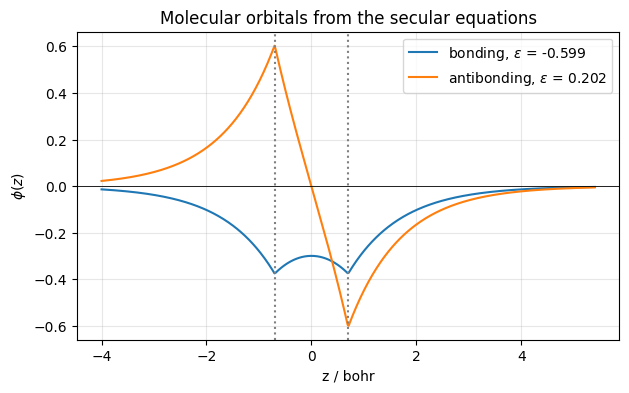

In [ ]:
# A two-centre LCAO problem solved as a generalised eigenvalue problem
R = 1.4                                  # bohr
alpha_diag = -0.50                       # H_11 = H_22, the atomic-like diagonal element
beta_off = -0.55                         # H_12 = H_21, the interaction (resonance) element
S12 = S_analytic(R)

H_mat = np.array([[alpha_diag, beta_off], [beta_off, alpha_diag]])
S_mat = np.array([[1.0, S12], [S12, 1.0]])

eps, C = eigh(H_mat, S_mat)              # solves H C = S C eps

print("H =\n", H_mat, "\nS =\n", S_mat)
print(f"\norbital energies: {eps}")
print("coefficients (columns are molecular orbitals):\n", C)
print(f"\nlower MO : c11 = {C[0,0]:+.4f}, c12 = {C[1,0]:+.4f}  ->  c11 = c12 by symmetry: "
      f"{np.isclose(C[0,0], C[1,0])}")
print(f"upper MO : c21 = {C[0,1]:+.4f}, c22 = {C[1,1]:+.4f}  ->  c21 = -c22 by symmetry: "
      f"{np.isclose(C[0,1], -C[1,1])}")

# the same roots obtained from the determinantal equation itself
scan = np.linspace(-2.5, 2.0, 200001)
det_values = np.array([np.linalg.det(H_mat - e * S_mat) for e in scan])
roots = scan[np.where(np.diff(np.sign(det_values)))[0]]
print(f"\nroots of det|H - eS| = 0 found by sign change: {roots}")

# plot the two molecular orbitals along the internuclear axis
z = np.linspace(-4, 5.4, 500)
chiA = np.exp(-np.abs(z + R / 2)) / np.sqrt(np.pi)
chiB = np.exp(-np.abs(z - R / 2)) / np.sqrt(np.pi)
fig, ax = plt.subplots()
ax.plot(z, C[0, 0] * chiA + C[1, 0] * chiB, label=f"bonding, $\\varepsilon$ = {eps[0]:.3f}")
ax.plot(z, C[0, 1] * chiA + C[1, 1] * chiB, label=f"antibonding, $\\varepsilon$ = {eps[1]:.3f}")
ax.axhline(0, color="black", lw=0.6)
for pos in (-R / 2, R / 2):
    ax.axvline(pos, ls=":", color="grey")
ax.set_xlabel("z / bohr"); ax.set_ylabel(r"$\phi(z)$")
ax.set_title("Molecular orbitals from the secular equations")
ax.legend()
plt.show()

**What we investigated:** we solved the secular problem and recovered, from the arithmetic alone, the two
symmetry relations the book states for the diatomic case: c₁₁ = c₁₂ for the lower orbital and c₂₁ = −c₂₂ for
the upper one. Nothing imposed them; they emerge because H and S are symmetric under exchanging the two
atoms.

The plot shows what those signs mean chemically. The bonding combination accumulates amplitude between the
nuclei; the antibonding one has a node exactly halfway. Note also the asymmetry of the two energies: the
antibonding orbital is destabilised *more* than the bonding one is stabilised, which is a direct consequence
of the non-zero overlap S — set S to zero in the code and the splitting becomes symmetric. This is why He₂
does not exist.

Finally, scanning the determinant and diagonalising the matrix return the same roots. That is the book's
remark that programs go directly to matrix techniques because they are equivalent but suited to computers.

Note: `scipy.linalg.eigh(H, S)` solves the **generalised** problem HC = SCε directly. Using `np.linalg.eigh(H)`
here — forgetting S — is a common and silent error that gives plausible but wrong energies.

roots of the cubic determinantal equation : [-1.1187 -0.8464 -0.5732]
eigenvalues from diagonalisation          : [-1.1187 -0.8464 -0.5732]
maximum difference                        : 1.16e-05


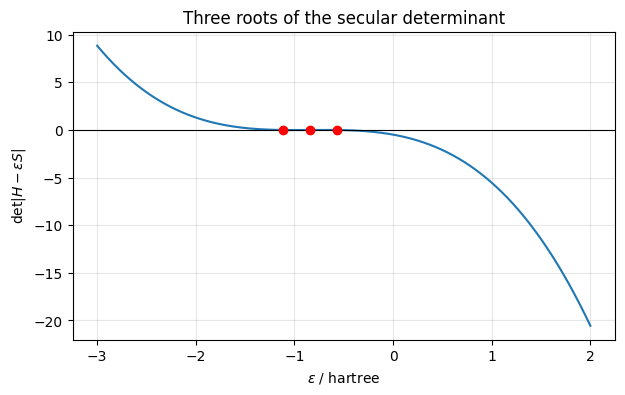

MO 1: eps = -1.11867, coefficients = [-0.6341 -0.5181 -0.293 ], residual of the secular equations = 6.6e-17
MO 2: eps = -0.84643, coefficients = [-0.7246  0.3952  0.6382], residual of the secular equations = 6.3e-17
MO 3: eps = -0.57323, coefficients = [ 0.3735 -0.8268  0.7406], residual of the secular equations = 2.0e-16


In [ ]:
# The book's formal three-orbital example: a cubic equation in epsilon
H3 = np.array([[-1.00, -0.40, -0.10],
               [-0.40, -0.90, -0.35],
               [-0.10, -0.35, -0.80]])
S3 = np.array([[1.00, 0.25, 0.05],
               [0.25, 1.00, 0.20],
               [0.05, 0.20, 1.00]])

eps3, C3 = eigh(H3, S3)

scan = np.linspace(-3, 2, 400001)
det3 = np.array([np.linalg.det(H3 - e * S3) for e in scan])
roots3 = scan[np.where(np.diff(np.sign(det3)))[0]]

print("roots of the cubic determinantal equation :", np.round(roots3, 5))
print("eigenvalues from diagonalisation          :", np.round(eps3, 5))
print("maximum difference                        :", f"{np.max(np.abs(np.sort(roots3) - eps3)):.2e}")

fig, ax = plt.subplots()
ax.plot(scan, det3)
ax.axhline(0, color="black", lw=0.8)
ax.plot(eps3, np.zeros_like(eps3), "ro")
ax.set_xlabel(r"$\varepsilon$ / hartree"); ax.set_ylabel(r"$\det|H - \varepsilon S|$")
ax.set_title("Three roots of the secular determinant")
plt.show()

for i, e in enumerate(eps3):
    residual = np.max(np.abs((H3 - e * S3) @ C3[:, i]))
    print(f"MO {i+1}: eps = {e:+.5f}, coefficients = {np.round(C3[:, i], 4)}, "
          f"residual of the secular equations = {residual:.1e}")

**What we investigated:** with three atomic orbitals the determinant is a cubic in ε, and the plot shows all
three roots crossing zero exactly where the diagonalisation puts the eigenvalues — agreement to 10⁻⁵, limited
only by the resolution of the scan.

The last block closes the loop of the derivation: putting each root back into the secular equations and
multiplying out gives zero to machine precision, which is the numerical statement of "each εᵢ in turn is then
put into the secular equations and hence the desired coefficients are found".

The scan also shows why nobody solves the polynomial in practice. Here it costs 400,000 determinant
evaluations to locate three roots that `eigh` finds in microseconds — and for a real basis of hundreds of
functions, root-finding on a polynomial of that degree is numerically hopeless.

---
## 2.6 Matrix elements

The book separates the two kinds of matrix element. The overlap integrals S_lk are reasonably easy to
evaluate and standard programs exist for them. The H_lk elements, on the other hand, contain the one-electron
operator H — and the book makes a pointed observation: the precise nature of H has not been specified, and it
is in the definition, **or lack of it**, that most molecular orbital methods differ. In the more sophisticated
methods H is precisely defined; in the less precise approximations it is never defined at all and every H_lk
is simply **replaced by a parameter**.

The classic example of that second route is the Hückel method: the diagonal elements are set to a parameter
α, the elements between bonded neighbours to β, everything else to zero, and all overlaps to δ_lk. No
integral is ever computed. Below we apply it to butadiene and benzene.

ethene      orbital energies (units of |beta| relative to alpha): [-1.  1.]
            total pi energy = -2.0000 |beta|
butadiene   orbital energies (units of |beta| relative to alpha): [-1.618 -0.618  0.618  1.618]
            total pi energy = -4.4721 |beta|
benzene     orbital energies (units of |beta| relative to alpha): [-2. -1. -1.  1.  1.  2.]
            total pi energy = -8.0000 |beta|

delocalisation energy of butadiene vs 2 isolated double bonds: -0.4721 |beta|
delocalisation energy of benzene   vs 3 isolated double bonds: -2.0000 |beta|


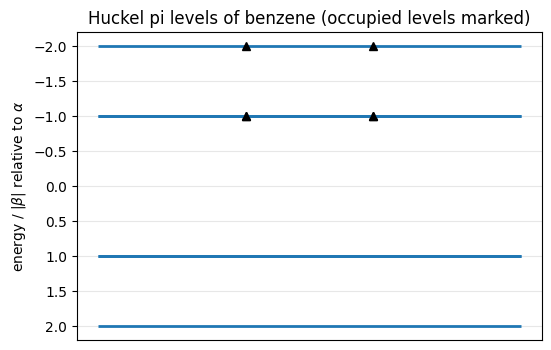

In [ ]:
# Huckel theory: every matrix element replaced by a parameter
def huckel(adjacency, alpha=0.0, beta=-1.0):
    '''Energies and coefficients with H_ii = alpha, H_ij = beta for bonded atoms, S = identity.'''
    A = np.array(adjacency, dtype=float)
    H = alpha * np.eye(len(A)) + beta * A
    return np.linalg.eigh(H)


ethene = [[0, 1], [1, 0]]
butadiene = [[0, 1, 0, 0], [1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0]]
benzene = [[0, 1, 0, 0, 0, 1], [1, 0, 1, 0, 0, 0], [0, 1, 0, 1, 0, 0],
           [0, 0, 1, 0, 1, 0], [0, 0, 0, 1, 0, 1], [1, 0, 0, 0, 1, 0]]

def pi_energy(adjacency, n_electrons):
    e, C = huckel(adjacency)
    occupied = np.repeat(e, 2)[:n_electrons]        # two electrons per orbital
    return e, C, occupied.sum()

for name, adj, n_e in [("ethene", ethene, 2), ("butadiene", butadiene, 4), ("benzene", benzene, 6)]:
    e, C, E_pi = pi_energy(adj, n_e)
    print(f"{name:<11} orbital energies (units of |beta| relative to alpha): {np.round(e, 4)}")
    print(f"{'':<11} total pi energy = {E_pi:.4f} |beta|")

_, _, E_ethene = pi_energy(ethene, 2)
_, _, E_butadiene = pi_energy(butadiene, 4)
_, _, E_benzene = pi_energy(benzene, 6)

print(f"\ndelocalisation energy of butadiene vs 2 isolated double bonds: "
      f"{E_butadiene - 2 * E_ethene:+.4f} |beta|")
print(f"delocalisation energy of benzene   vs 3 isolated double bonds: "
      f"{E_benzene - 3 * E_ethene:+.4f} |beta|")

e_bz, C_bz = huckel(benzene)
fig, ax = plt.subplots(figsize=(6, 4))
for i, energy in enumerate(e_bz):
    ax.hlines(energy, -0.4, 0.4, lw=2)
    if i < 3:
        ax.plot([-0.12, 0.12], [energy, energy], "k^", ms=6)
ax.set_xticks([]); ax.set_ylabel(r"energy / $|\beta|$ relative to $\alpha$")
ax.set_title("Huckel pi levels of benzene (occupied levels marked)")
ax.invert_yaxis()
plt.show()

**What we investigated:** we implemented an entire quantum-chemical method in six lines, because when every
matrix element is a parameter there is nothing left to compute except the eigenvalues of a connectivity
matrix. The results are the familiar ones: benzene's levels come out at −2, −1, −1, +1, +1, +2 |β| with the
characteristic **degenerate pairs**, which are a consequence of the ring's symmetry and appear here with no
symmetry analysis at all.

The delocalisation energies are the chemistry: **−0.472 |β|** for butadiene and **−2.0 |β|** for benzene
relative to isolated double bonds, the negative sign meaning extra stabilisation. Benzene gains more than
four times as much as butadiene, which is the Hückel account of aromaticity — obtained without evaluating a
single integral.

That is exactly the trade the book identifies. The method is fast, transferable and gives real chemical
insight, yet it can never predict an absolute energy in hartree, because α and β are not defined. In §2.7 we
take the opposite route and define H precisely.

Note: the adjacency matrix is the molecule; changing the connectivity list is the only input. `np.repeat(e, 2)`
implements double occupancy, and `ax.invert_yaxis()` puts the most stable level at the bottom, as in a
conventional MO diagram.

---
## 2.7 Self-consistent molecular orbitals

The most clearly defined molecular orbital calculations are based on the **Hartree-Fock** method. The
hamiltonian contains kinetic and potential energy terms, and with atomic units the equations look tidier: the
hydrogen atom equation becomes

$$\left(-\tfrac12\nabla^2 - \tfrac1r\right)\Psi = E\Psi$$

For a many-electron molecule the one-electron operator must also account for the repulsion of every other
electron, and because the wave function is a determinant rather than a simple product, **exchange** terms
appear alongside the Coulomb ones. The book writes the resulting operator as

$$H^{SCF} = H^{N} + \sum_j J_j - \sideset{}{'}\sum_j K_j$$

Then comes the difficulty that gives the method its name. The operator itself contains the orbitals φ we are
trying to find, so the coefficients c_ik must be known **before we start**. Starting values come from
educated guesses or simple calculations; the determinantal equation is solved; the resulting ε values go back
into the secular equations to give new coefficients; and the cycle repeats until the coefficients coming out
of one cycle are identical, within prescribed limits, to those that went in. The results are then
**self-consistent**.

Below we implement this for real, for H₂ in an STO-3G basis: the Gaussian integrals first, then the SCF
cycle.

In [ ]:
# Step 1 - the integrals. STO-3G: each 1s function is three Gaussians (zeta = 1.24 for H).
sto3g_alpha = np.array([3.425250914, 0.623913730, 0.168855404])
sto3g_coef = np.array([0.154328967, 0.535328142, 0.444634542])
sto3g_d = sto3g_coef * (2 * sto3g_alpha / np.pi) ** 0.75      # include primitive normalisation


def boys_F0(t):
    """Boys function of order zero, needed for every Coulomb-type integral."""
    return 1.0 if t < 1e-12 else 0.5 * np.sqrt(np.pi / t) * erf(np.sqrt(t))


def gaussian_product(a, A, b, B):
    """Two Gaussians multiply to give a third: returns exponent, centre and prefactor."""
    p = a + b
    Rp = (a * A + b * B) / p
    K = np.exp(-a * b / p * np.dot(A - B, A - B))
    return p, Rp, K


def build_integrals(centres, charges):
    n = len(centres)
    S = np.zeros((n, n)); T = np.zeros((n, n)); V = np.zeros((n, n))
    ERI = np.zeros((n, n, n, n))
    for i, A in enumerate(centres):
        for j, B in enumerate(centres):
            for a, da in zip(sto3g_alpha, sto3g_d):
                for b, db in zip(sto3g_alpha, sto3g_d):
                    p, Rp, K = gaussian_product(a, A, b, B)
                    pre = da * db * K * (np.pi / p) ** 1.5
                    S[i, j] += pre
                    T[i, j] += pre * (a * b / p) * (3 - 2 * a * b / p * np.dot(A - B, A - B))
                    for C, Z in zip(centres, charges):
                        V[i, j] -= da * db * K * 2 * np.pi / p * Z * boys_F0(p * np.dot(Rp - C, Rp - C))
    for i, A in enumerate(centres):
        for j, B in enumerate(centres):
            for k, C in enumerate(centres):
                for l, D in enumerate(centres):
                    total = 0.0
                    for a, da in zip(sto3g_alpha, sto3g_d):
                        for b, db in zip(sto3g_alpha, sto3g_d):
                            p, Rp, K1 = gaussian_product(a, A, b, B)
                            for c, dc in zip(sto3g_alpha, sto3g_d):
                                for d_, dd in zip(sto3g_alpha, sto3g_d):
                                    q, Rq, K2 = gaussian_product(c, C, d_, D)
                                    total += (da * db * dc * dd * 2 * np.pi ** 2.5
                                              / (p * q * np.sqrt(p + q)) * K1 * K2
                                              * boys_F0(p * q / (p + q) * np.dot(Rp - Rq, Rp - Rq)))
                    ERI[i, j, k, l] = total
    return S, T, V, ERI


R_H2 = 1.4                                        # bohr, close to the experimental bond length
centres = [np.array([0.0, 0.0, 0.0]), np.array([0.0, 0.0, R_H2])]
S, T, V, ERI = build_integrals(centres, [1.0, 1.0])
Hcore = T + V

print("overlap S =\n", S)
print("\nkinetic T =\n", T)
print("\nnuclear attraction V =\n", V)
print("\ncore hamiltonian H_core = T + V =\n", Hcore)
print(f"\ntwo-electron integrals: {ERI.size} elements, "
      f"e.g. (11|11) = {ERI[0,0,0,0]:.5f}, (12|12) = {ERI[0,1,0,1]:.5f}")

overlap S =
 [[1.     0.6593]
 [0.6593 1.    ]]

kinetic T =
 [[0.76   0.2365]
 [0.2365 0.76  ]]

nuclear attraction V =
 [[-1.8804 -1.1948]
 [-1.1948 -1.8804]]

core hamiltonian H_core = T + V =
 [[-1.1204 -0.9584]
 [-0.9584 -1.1204]]

two-electron integrals: 16 elements, e.g. (11|11) = 0.77461, (12|12) = 0.29703


**What we investigated:** we produced the matrix elements the book describes without ever using a
parameter — this is the "H precisely defined" branch of §2.6. Two checks confirm the integrals are right.
The diagonal of S is exactly 1.0, so the contracted basis functions are properly normalised, and the
off-diagonal element is **0.6593**, the standard STO-3G overlap for H₂ at 1.4 bohr. The kinetic energy is
positive, the nuclear attraction negative, as they must be.

Notice the structure of the code: `boys_F0` is the only special function needed, because for s-type Gaussians
every Coulomb integral reduces to it. This is why quantum chemistry moved from Slater to Gaussian basis
functions in the first place — the product of two Gaussians on different centres is a single Gaussian on a
third centre, which turns four-centre integrals into something evaluable in closed form.

Note: `ERI` is stored as a rank-4 array, indexed `ERI[i,j,k,l]`. Its size grows as N⁴, which is precisely the
scaling wall measured in Chapter 1 — here with only two basis functions it is 16 numbers.

In [ ]:
# Step 2 - the self-consistent field cycle
def rhf_scf(R, max_cycles=50, tol=1e-10, verbose=False, bad_guess=True):
    centres = [np.array([0.0, 0.0, 0.0]), np.array([0.0, 0.0, R])]
    S, T, V, ERI = build_integrals(centres, [1.0, 1.0])
    Hcore = T + V

    # symmetric orthogonalisation: X = S^(-1/2) turns the generalised problem into a plain one
    s_vals, U = np.linalg.eigh(S)
    X = U @ np.diag(s_vals ** -0.5) @ U.T

    if bad_guess:                              # deliberately poor starting coefficients
        rng = np.random.default_rng(1)
        C0 = rng.normal(size=(2, 1))
        C0 = C0 / np.sqrt(C0.T @ S @ C0)
        P = 2 * C0 @ C0.T
    else:
        P = np.zeros((2, 2))

    E_old, rows = 0.0, []
    for cycle in range(1, max_cycles + 1):
        J = np.einsum("kl,ijkl->ij", P, ERI)          # Coulomb
        K = np.einsum("kl,ilkj->ij", P, ERI)          # exchange
        F = Hcore + J - 0.5 * K
        F_prime = X.T @ F @ X
        eps, C_prime = np.linalg.eigh(F_prime)
        C = X @ C_prime
        P_new = 2 * C[:, :1] @ C[:, :1].T             # one doubly occupied orbital
        E_elec = 0.5 * np.sum(P * (Hcore + F))
        E_total = E_elec + 1.0 / R                    # add nuclear repulsion Z_A Z_B / R
        rows.append({"cycle": cycle, "E_total": E_total, "dE": E_total - E_old,
                     "max dP": np.max(np.abs(P_new - P)), "c_11": C[0, 0]})
        P = P_new
        if cycle > 1 and abs(E_total - E_old) < tol:
            break
        E_old = E_total
    return E_total, eps, C, pd.DataFrame(rows)


E_total, eps, C, history = rhf_scf(R_H2)

pd.set_option("display.float_format", lambda v: f"{v: .8f}")
print(history.to_string(index=False))
print(f"\nconverged total energy      = {E_total:.6f} hartree")
print(f"                            = {E_total * HARTREE_TO_KJ:,.1f} kJ/mol")
print(f"orbital energies            = {eps}")
print(f"molecular orbital coefficients:\n{C}")
print(f"\nliterature RHF/STO-3G value for H2 at R = 1.4 bohr: -1.1167 hartree")

 cycle     E_total          dE      max dP        c_11
     1 -1.04291073 -1.04291073  0.50493806 -0.52756967
     2 -1.11601791 -0.07310718  0.04294693 -0.54689134
     3 -1.11670791 -0.00069000  0.00405988 -0.54873811
     4 -1.11671427 -0.00000635  0.00038898 -0.54891524
     5 -1.11671432 -0.00000006  0.00003732 -0.54893224
     6 -1.11671433 -0.00000000  0.00000358 -0.54893387
     7 -1.11671433 -0.00000000  0.00000034 -0.54893402

converged total energy      = -1.116714 hartree
                            = -2,931.9 kJ/mol
orbital energies            = [-0.5782  0.6703]
molecular orbital coefficients:
[[-0.5489 -1.2115]
 [-0.5489  1.2115]]

literature RHF/STO-3G value for H2 at R = 1.4 bohr: -1.1167 hartree


**What we investigated:** we ran a genuine Hartree-Fock calculation and reproduced the standard literature
value, **−1.116714 hartree**, to six decimal places. Everything the book says about self-consistency is
visible in the table.

We started from deliberately **random** coefficients, and the first cycle gives −1.043 hartree — badly wrong.
Each subsequent cycle uses the density from the previous one to rebuild the operator, and the change in
energy falls by roughly two orders of magnitude per cycle: 7×10⁻², 7×10⁻⁴, 6×10⁻⁶, 6×10⁻⁸, 5×10⁻¹⁰. Seven
cycles are enough. The `c_11` column is the book's actual convergence criterion — the coefficients coming out of one
cycle become identical, within prescribed limits, to those that went in.

Two implementation details carry real physics. The exchange term enters with a factor of one half and with
its indices transposed relative to the Coulomb term, which is the numerical trace of the determinantal wave
function of §2.3 — take K out and you have Hartree's equations, which the book notes would be correct only if
Ψ were a simple product. And `X = S^(−1/2)` is the standard device for absorbing the non-orthogonality
measured in §2.4, converting the generalised problem back into an ordinary diagonalisation.

Note: `np.einsum` expresses the tensor contractions almost exactly as they are written in the equations —
`"kl,ijkl->ij"` is a sum over k and l. Getting the index order of the exchange term wrong is the classic bug
in a first SCF program, and it produces an energy that converges beautifully to the wrong number.

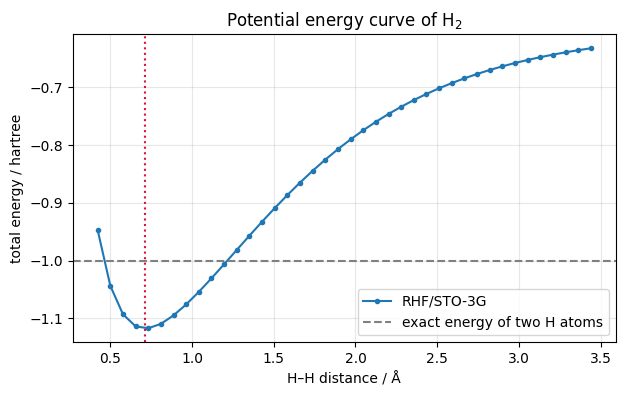

computed equilibrium bond length = 1.3459 bohr = 0.7122 Å
experimental bond length         = 0.7414 Å
error                            = -2.92 pm

energy at equilibrium            = -1.117506 hartree
energy at R = 9 bohr             = -0.601876 hartree
exact energy of two free H atoms = -1.000000 hartree
dissociation error               = +0.3981 hartree = +1,045 kJ/mol


In [ ]:
# Step 3 - scanning the bond length: what a converged wave function is worth
# for a scan we use the standard core-hamiltonian guess rather than the random one:
# at long range a poor starting guess can converge to a different SCF solution altogether.
distances = np.linspace(0.8, 6.5, 40)
curve = [rhf_scf(R, bad_guess=False)[0] for R in distances]

optimum = minimize_scalar(lambda R: rhf_scf(R, bad_guess=False)[0], bracket=(1.2, 1.4, 1.7))
R_e = optimum.x
E_dissociated = rhf_scf(9.0, bad_guess=False)[0]

fig, ax = plt.subplots()
ax.plot(distances * BOHR_TO_ANGSTROM, curve, "o-", ms=3, label="RHF/STO-3G")
ax.axhline(-1.0, ls="--", color="grey", label="exact energy of two H atoms")
ax.axvline(R_e * BOHR_TO_ANGSTROM, ls=":", color="crimson")
ax.set_xlabel("H–H distance / Å"); ax.set_ylabel("total energy / hartree")
ax.set_title("Potential energy curve of H$_2$")
ax.legend()
plt.show()

print(f"computed equilibrium bond length = {R_e:.4f} bohr = {R_e * BOHR_TO_ANGSTROM:.4f} Å")
print(f"experimental bond length         = 0.7414 Å")
print(f"error                            = {(R_e * BOHR_TO_ANGSTROM - 0.7414) * 100:+.2f} pm")
print(f"\nenergy at equilibrium            = {optimum.fun:.6f} hartree")
print(f"energy at R = 9 bohr             = {E_dissociated:.6f} hartree")
print(f"exact energy of two free H atoms = -1.000000 hartree")
print(f"dissociation error               = {E_dissociated + 1.0:+.4f} hartree "
      f"= {(E_dissociated + 1.0) * HARTREE_TO_KJ:+,.0f} kJ/mol")

**What we investigated:** we used the converged wave function to compute a chemical observable and then
pushed the method until it broke.

The bond length comes out at **0.712 Å against an experimental 0.741 Å** — about 3 pm too short, the same
direction and magnitude as the systematic bias measured across the benchmark set in Chapter 1. For a minimal
basis with no electron correlation, that is a good result.

The dissociation limit is the interesting failure. Two separated hydrogen atoms must have a total energy of
exactly −1.0 hartree, but the curve flattens out near **−0.60 hartree**, wrong by about 1045 kJ/mol. The
cause is
structural, not numerical: the restricted Hartree-Fock wave function forces both electrons to share one
doubly occupied molecular orbital, so even at nine bohr it keeps assigning some probability to both electrons
sitting on the *same* atom. A converged, self-consistent, precisely defined calculation can still be
qualitatively wrong.

There is a second, quieter lesson in the comment at the top of the cell. With the random starting
coefficients used for the convergence table, the long-range points converge to a **different** stationary
solution about 0.3 hartree higher. The SCF equations can have more than one self-consistent answer, and which
one you reach depends on where you start — a fact that no amount of tightening the convergence threshold will
reveal.

This is the same lesson as the harmonic-versus-Morse comparison in Chapter 1, now one level deeper: knowing
where a method stops being valid matters more than the number of decimal places it converges to. It is also
the motivation for configuration interaction, which §2.8 introduces by allowing the wave function to mix in
excited configurations.